In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import matplotlib.pyplot as plt
import os
from matplotlib.gridspec import GridSpec
import seaborn as sns
import ast

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
def plot_timeline_with_ci_combined(evidence_df, intuition_df, time_column, 
                                   evidence_mean_col, evidence_ci_lower_col, evidence_ci_upper_col,
                                   intuition_mean_col, intuition_ci_lower_col, intuition_ci_upper_col,
                                   ylabel, dataset):
    """
    Plots combined timelines with confidence intervals for evidence and intuition.
    Includes the original scores as a solid line and the aggregated mean as a dashed line.
    """

    # Define colors
    green = "#228833"
    yellow = "#DDCC77"
    black = "#000000"
    
    plt.figure(figsize=(12, 6))
    
    # Plot Evidence
    plt.plot(evidence_df[time_column].astype(str), evidence_df[evidence_mean_col], label='Evidence (Original)', color=green, linewidth=2)
    plt.plot(evidence_df[time_column].astype(str), evidence_df['evidence_score_w2vparliament'], 
             label='Evidence Median', color=green, linestyle='--', linewidth=2)
    plt.fill_between(
        evidence_df[time_column].astype(str),
        evidence_df[evidence_ci_lower_col],
        evidence_df[evidence_ci_upper_col],
        color=green,
        alpha=0.2,
        label='Evidence 95% CI'
    )
    
    # Plot Intuition
    plt.plot(intuition_df[time_column].astype(str), intuition_df[intuition_mean_col], label='Intuition (Original)', color=yellow, linewidth=2)
    plt.plot(intuition_df[time_column].astype(str), intuition_df['intuition_score_w2vparliament'], 
             label='Intuition Median', color=yellow, linestyle='--', linewidth=2)
    plt.fill_between(
        intuition_df[time_column].astype(str),
        intuition_df[intuition_ci_lower_col],
        intuition_df[intuition_ci_upper_col],
        color=yellow,
        alpha=0.2,
        label='Intuition 95% CI'
    )
    
    plt.xlabel('Quarter', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.ylim(0, 0.5) 
    plt.xticks(rotation=45, fontsize=10)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"bootstrapped_ci_with_dashed_{dataset}.png")
    plt.show()




In [3]:
def plot_timeseries(df, dataset, time_col):

    # Ensure the `video_published` column is in datetime format
    df[time_col] = pd.to_datetime(df[time_col])
    
    # Convert to quarterly periods
    df['quarter'] = df[time_col].dt.to_period('Q')
    
    quarterly_aggregated_evidence = df.groupby('quarter').agg({
        'evidence_score_w2vparliament': 'mean',
        #'evidence_mean': 'mean',# Average the evidence mean
        'evidence_median': 'mean',# Average the evidence mean
        'evidence_ci_low': 'mean',  # Average the lower bound of CI
        'evidence_ci_high': 'mean'   # Average the upper bound of CI
    }).reset_index()
    
    quarterly_aggregated_intuition = df.groupby('quarter').agg({
        'intuition_score_w2vparliament': 'mean',
        #'intuition_mean': 'mean',# Average the intuition mean
        'intuition_median': 'mean',
        'intuition_ci_low': 'mean',  # Average the lower bound of CI
        'intuition_ci_high': 'mean'   # Average the upper bound of CI
    }).reset_index()
    
    
    # Example usage with the quarterly aggregated data (assuming they are already created)
    plot_timeline_with_ci_combined(
        evidence_df=quarterly_aggregated_evidence,
        intuition_df=quarterly_aggregated_intuition,
        time_column='quarter',
        evidence_mean_col='evidence_median',
        evidence_ci_lower_col='evidence_ci_low',
        evidence_ci_upper_col='evidence_ci_high',
        intuition_mean_col='intuition_median',
        intuition_ci_lower_col='intuition_ci_low',
        intuition_ci_upper_col='intuition_ci_high',
        ylabel='Aggregated Scores',
        dataset = dataset
    )

In [4]:
df_yt = pd.read_csv("/kaggle/input/final-data/videos_all.csv")
df_speeches = pd.read_csv("/kaggle/input/final-data/speeches.csv")
df_twitter = pd.read_csv("/kaggle/input/final-data/twitter.csv")

/tmp/ipykernel_17/2588735772.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_speeches = pd.read_csv("/kaggle/input/final-data/speeches.csv")


In [5]:
# Drop columns with '_x' suffix
df_yt = df_yt.drop(columns=[col for col in df_yt.columns if col.endswith('_y')], errors='ignore')

# Rename columns with '_y' suffix to remove '_y'
df_yt = df_yt.rename(columns={col: col[:-2] for col in df_yt.columns if col.endswith('_x')})

/tmp/ipykernel_17/2036806209.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['quarter'] = df[time_col].dt.to_period('Q')


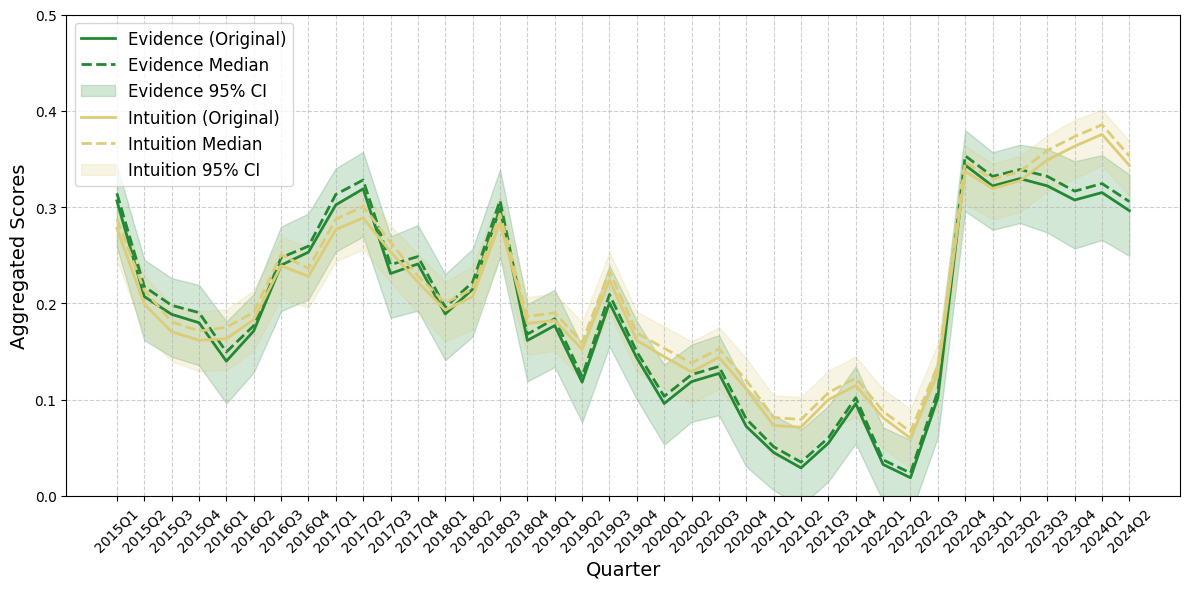

/tmp/ipykernel_17/2036806209.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['quarter'] = df[time_col].dt.to_period('Q')


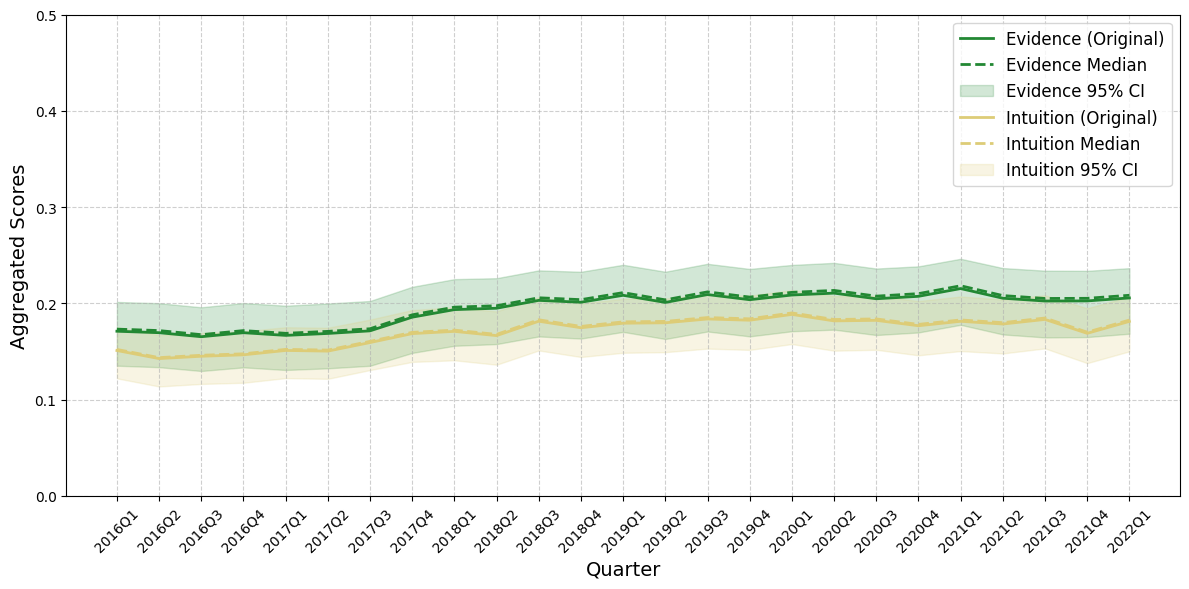

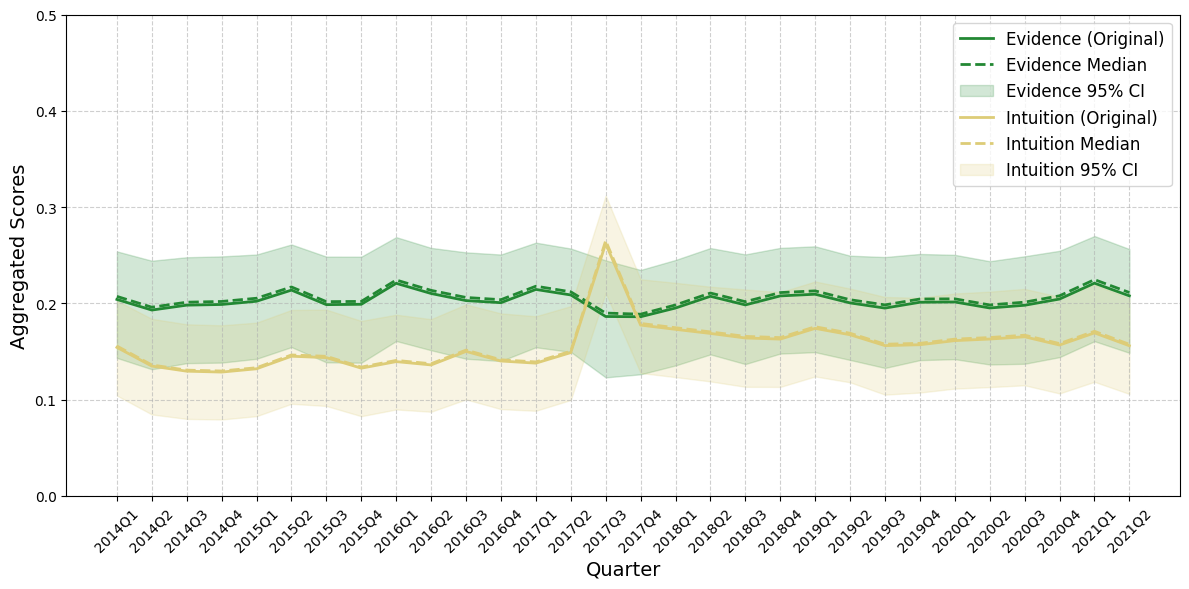

In [6]:
plot_timeseries(df_yt, "youtube", "published_at")
plot_timeseries(df_twitter, "twitter", "created_at")
plot_timeseries(df_speeches, "speeches", "date")


In [7]:
bootstrap_df_yt = pd.read_csv("/kaggle/input/final-data/youtube_corpus.csv")
bootstrap_df_twitter = pd.read_csv("/kaggle/input/final-data/twitter_corpus.csv")
bootstrap_df_speeches = pd.read_csv("/kaggle/input/final-data/speeches_corpus.csv")

In [8]:
def plot_boxplots(bootstrap_df, data_name):
    top_100_words = bootstrap_df.nlargest(36, 'frequency')
    # Prepare data for box plot
    long_data = pd.DataFrame()
    
    for _, row in top_100_words.iterrows():
        for category in ['evidence', 'intuition']:
            long_data = pd.concat([
                long_data,
                pd.DataFrame({
                    'word': row['word'],
                    'category': category,
                    'values': [
                        row[f'{category}_min'],
                        row[f'{category}_25th_percentile'],
                        row[f'{category}_median'],
                        row[f'{category}_75th_percentile'],
                        row[f'{category}_max']
                    ]
                })
            ])


    # Set a color palette for evidence and intuition
    palette = {"evidence": "#228833", "intuition": "#DDCC77"}
    
    
    # Adjusting figure size for increased height
    unique_words = top_100_words['word'].unique()
    num_words = len(unique_words)
    cols = 6  # Number of columns
    rows = (num_words // cols) + 1
    
    fig, axes = plt.subplots(rows, cols, figsize=(24, 20), constrained_layout=True)
    
    # Plot each word
    for i, word in enumerate(unique_words):
        ax = axes[i // cols, i % cols]
        data = long_data[long_data['word'] == word]
        sns.boxplot(
        data=data, 
        x="category", 
        y="values", 
        hue="category",  
        ax=ax, 
        palette=palette,
        width=0.7,  # Adjust width of the boxes
        boxprops=dict(edgecolor="gray", linewidth=1.2),  # Set edge color
        medianprops=dict(color="black", linewidth=1.5),  # Make median line clearer
        whiskerprops=dict(color="gray", linewidth=1),  # Adjust whiskers
        capprops=dict(color="gray", linewidth=1),  # Adjust caps
        flierprops=dict(marker="o", markerfacecolor="black", markersize=3, markeredgewidth=0, alpha=0.5)  # Make outliers less prominent
    )
        ax.set_title(word, fontsize=10)
        ax.set_xticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", left=False)  # Remove y-axis ticks
        ax.set_ylim(-0.8, 0.8)  # Set y-axis limits from -1 to 1
        ax.legend().remove()
    
    # Remove empty subplots
    for i in range(len(unique_words), rows * cols):
        fig.delaxes(axes.flatten()[i])
    
    # Add global legend
    handles = [
        plt.Line2D([0], [0], color=palette["evidence"], lw=4, label="Evidence"),
        plt.Line2D([0], [0], color=palette["intuition"], lw=4, label="Intuition")
    ]
    fig.legend(handles=handles, loc="upper center", fontsize=12, ncol=2, bbox_to_anchor=(0.5, 0.98))
    
    # Display the plot
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for legend space
    plt.savefig(f"corpus_words_boxplot_{data_name}.pdf", format="pdf", dpi=300)
    plt.show()

/tmp/ipykernel_17/2641188606.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for legend space


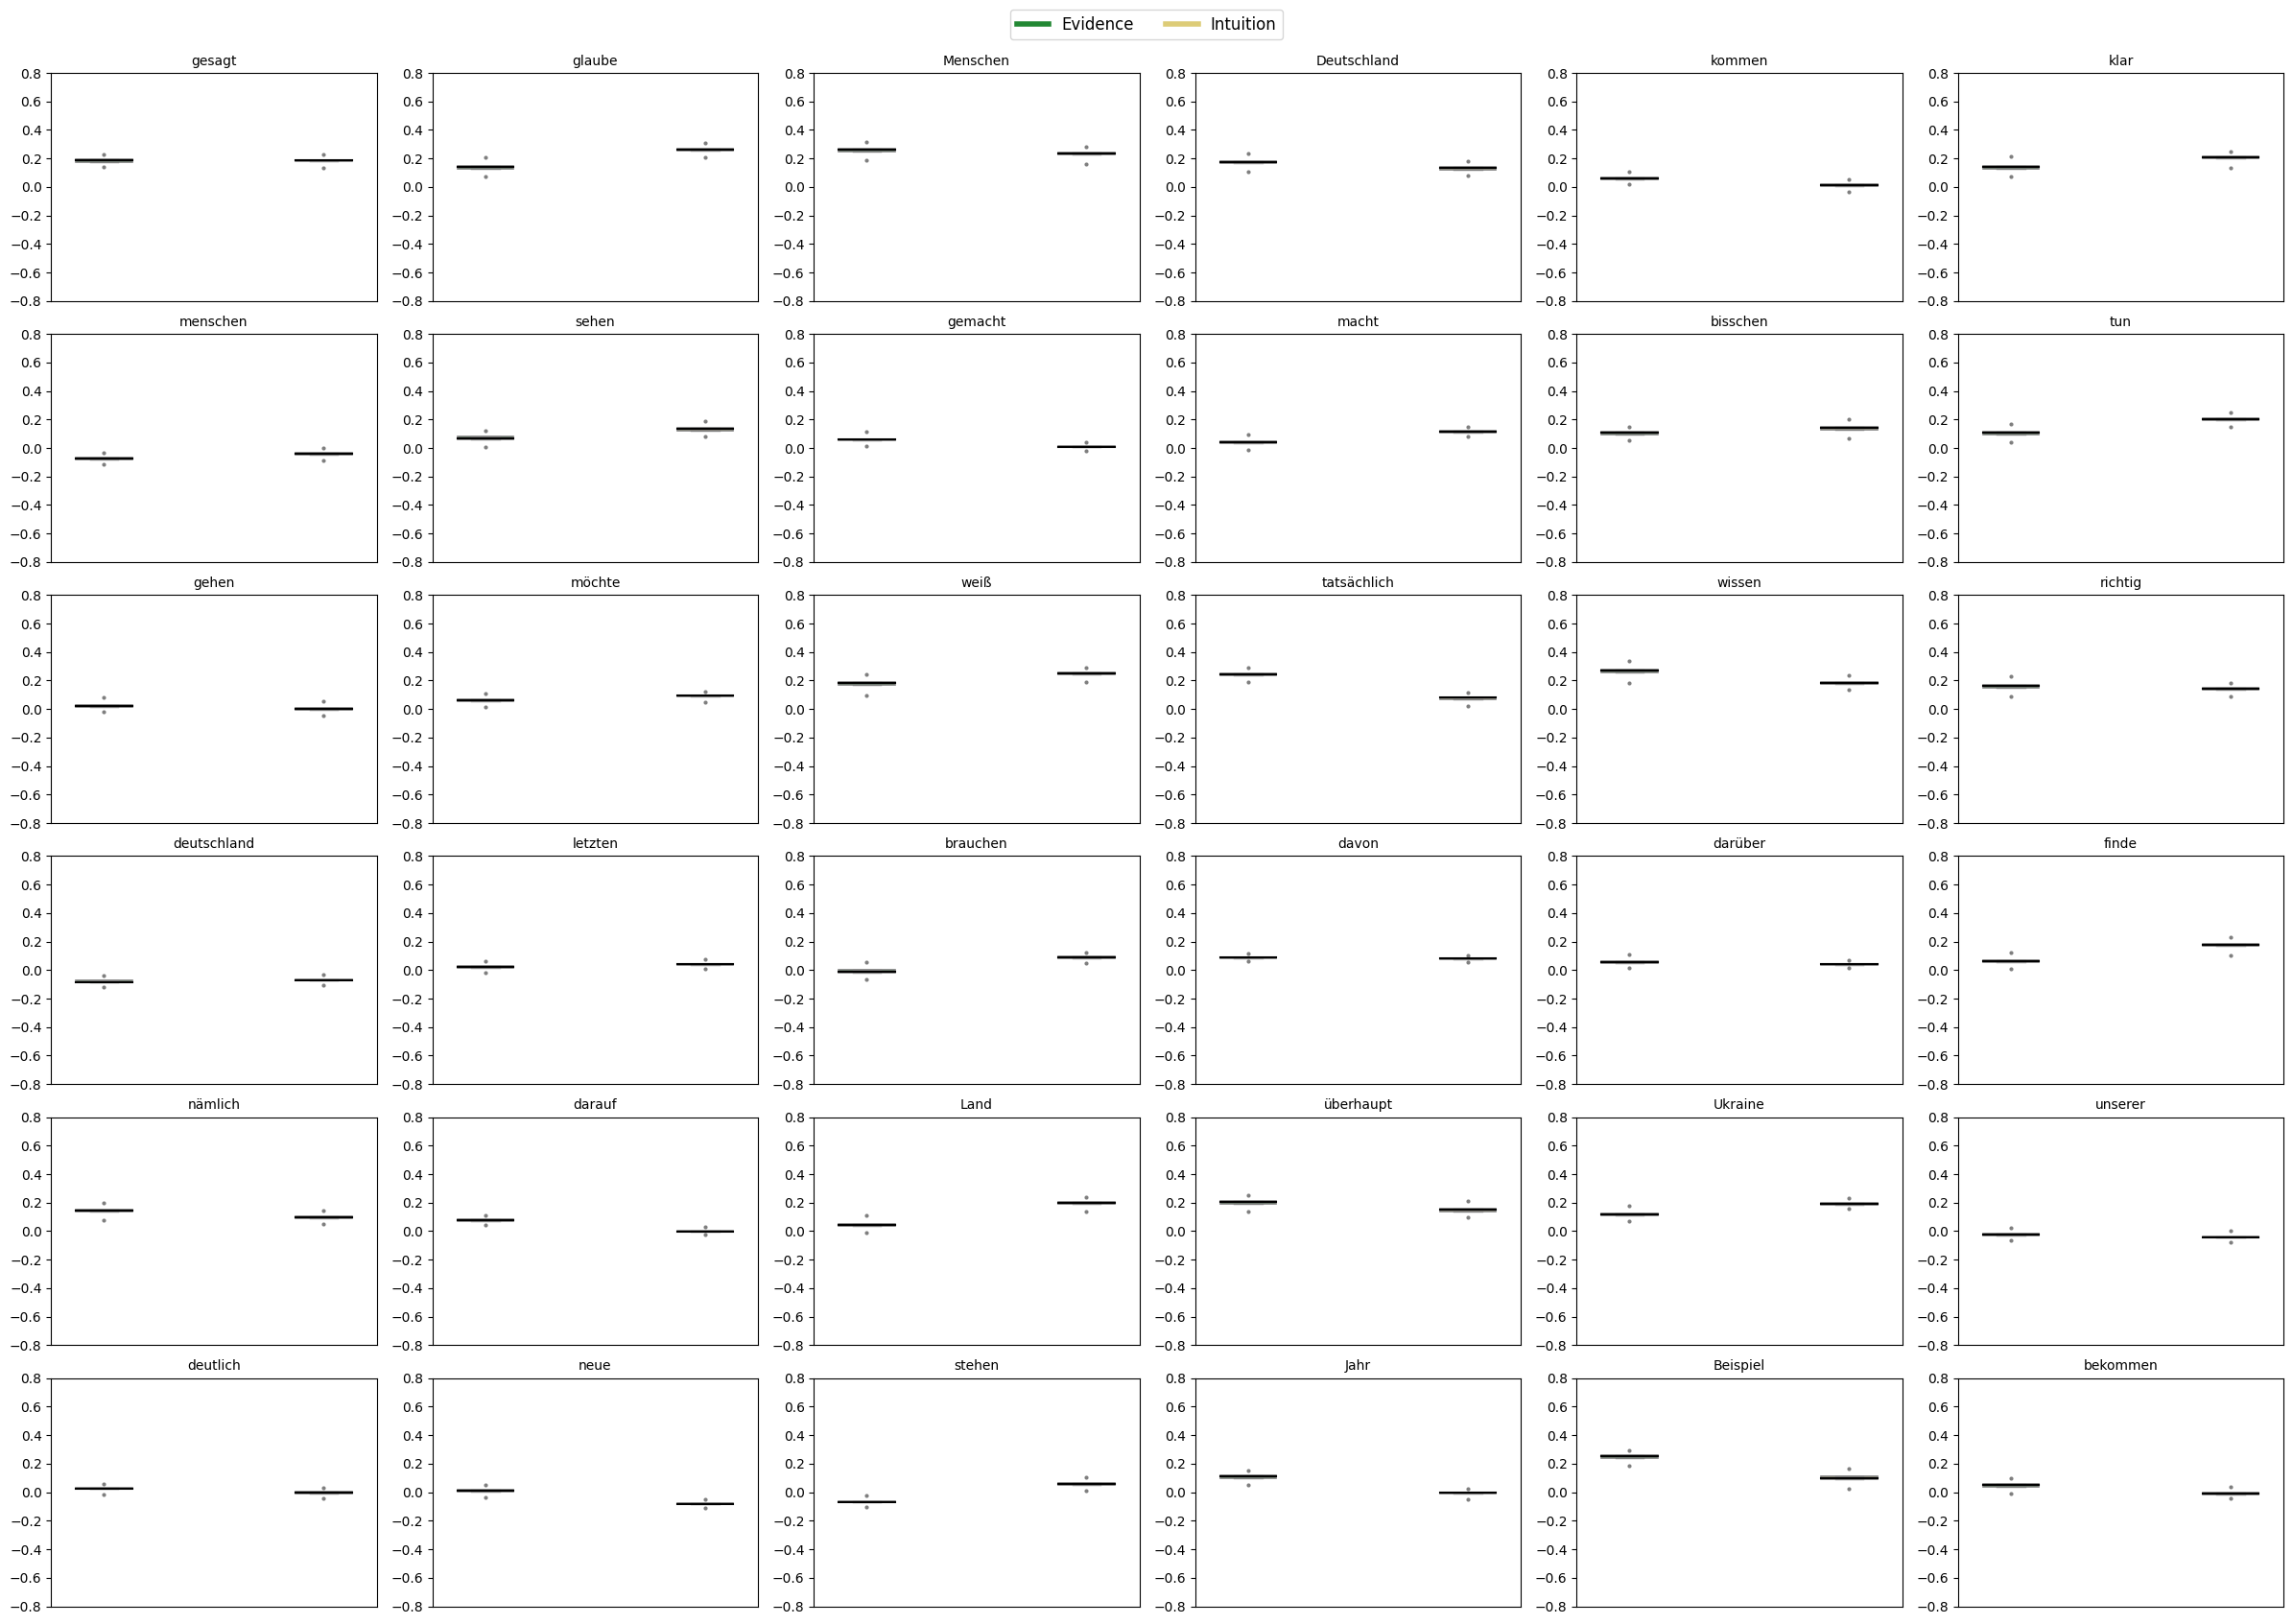

/tmp/ipykernel_17/2641188606.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for legend space


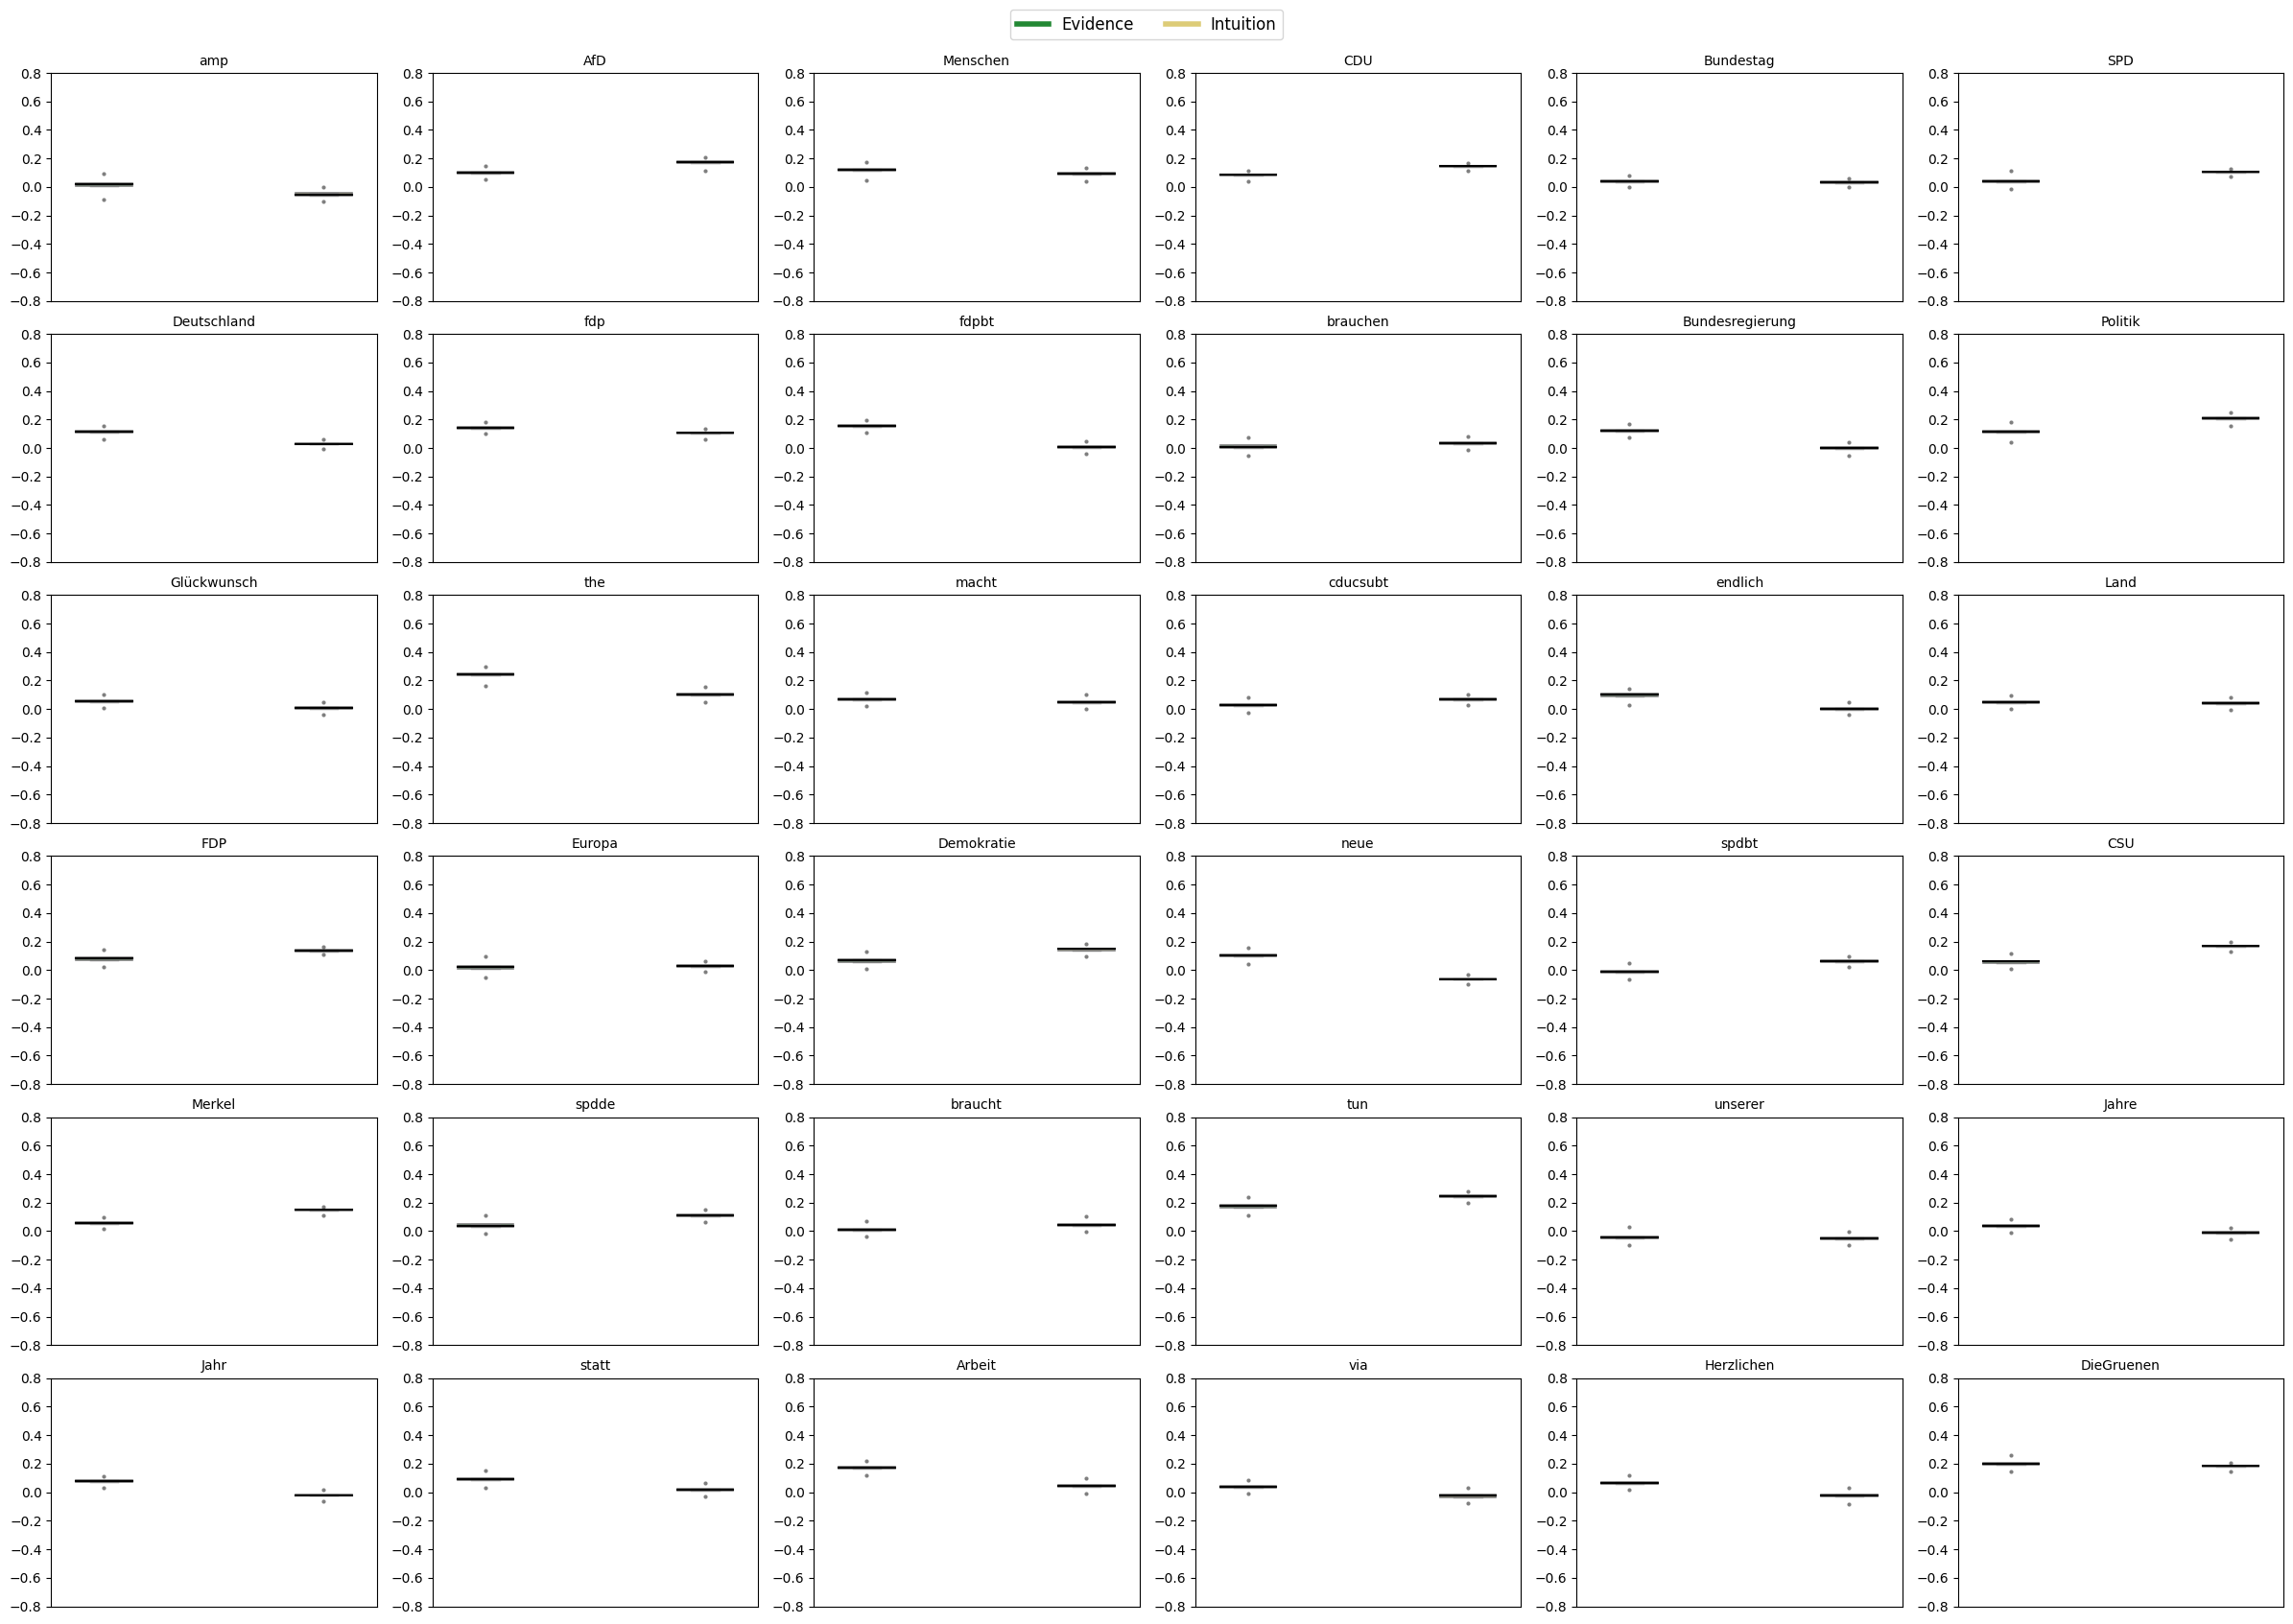

/tmp/ipykernel_17/2641188606.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for legend space


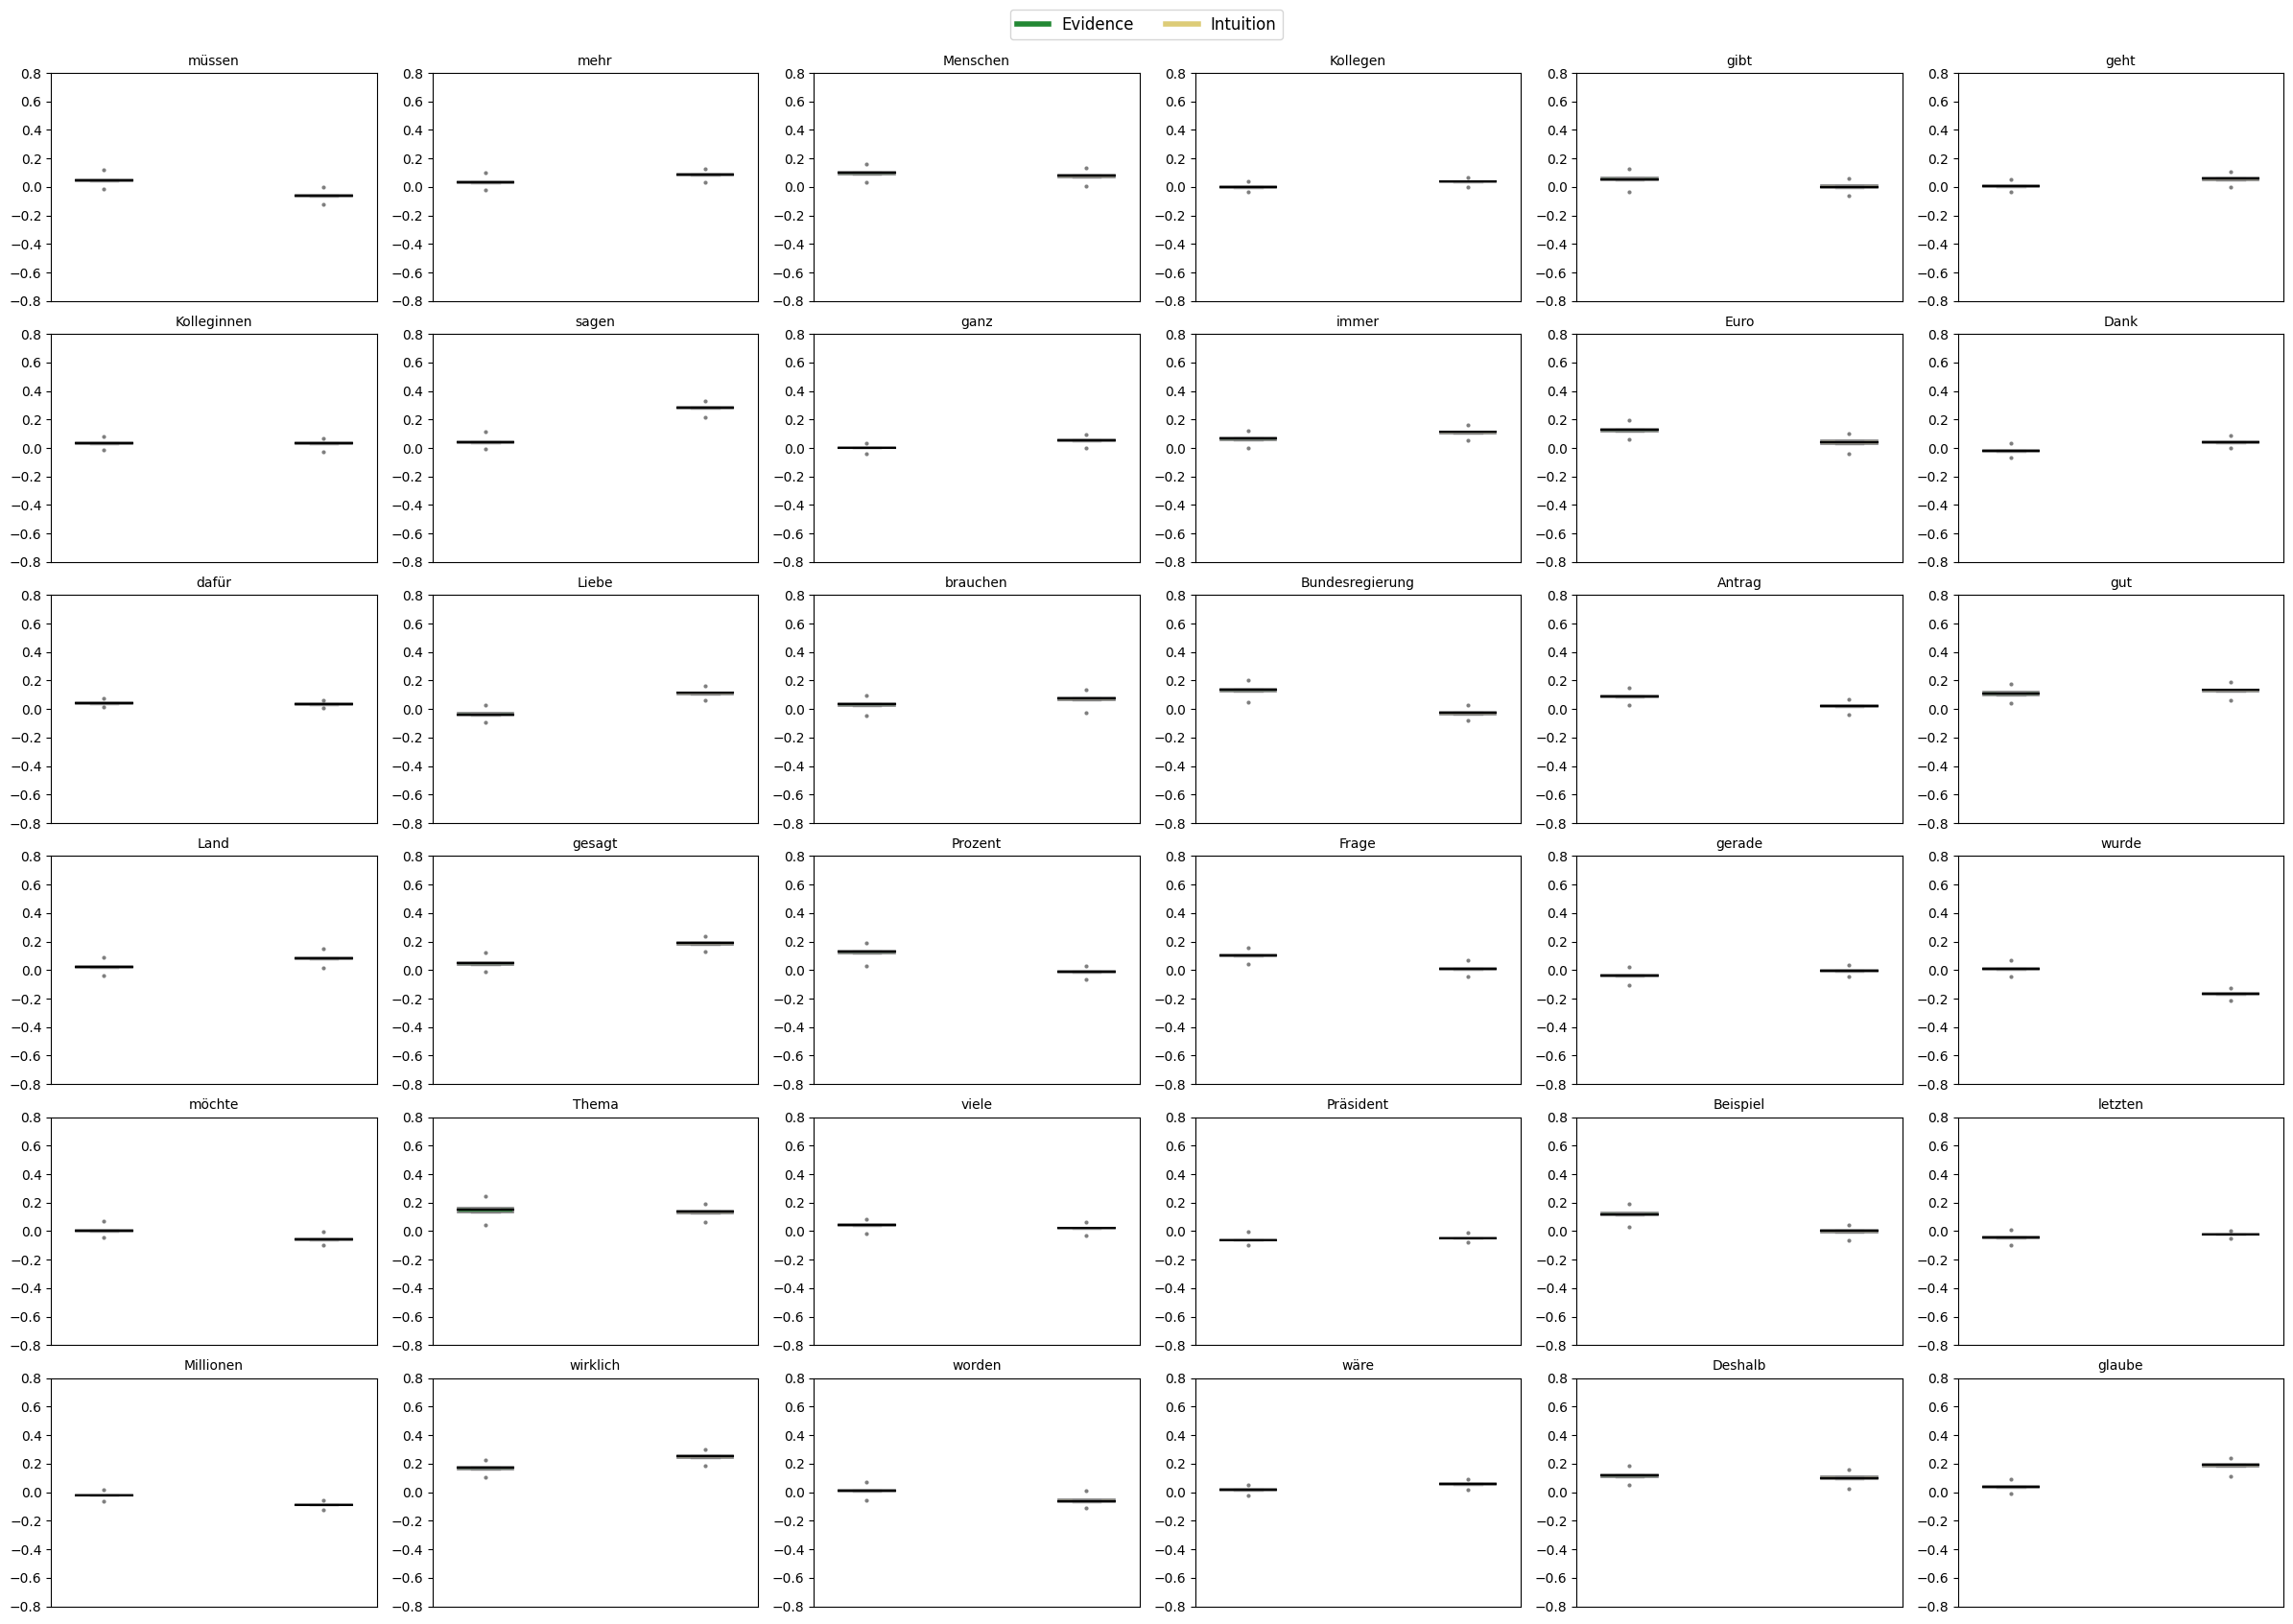

In [9]:
plot_boxplots(bootstrap_df_yt, "youtube")
plot_boxplots(bootstrap_df_twitter, "twitter")
plot_boxplots(bootstrap_df_speeches, "speeches")

In [10]:
bootstrap_df_yt = pd.read_csv("/kaggle/input/bootstrapp/youtube_corpus_bootstrap_statistic.csv")
bootstrap_df_twitter = pd.read_csv("/kaggle/input/bootstrapp/twitter_corpus_bootstrap_statistic.csv")
bootstrap_df_speeches = pd.read_csv("/kaggle/input/bootstrapp/speeches_corpus_bootstrap_statistic.csv")

In [11]:
bootstrap_df_yt.keys()

Index(['word', 'evidence_variance', 'evidence_mean', 'evidence_median',
       'evidence_min', 'evidence_max', 'evidence_25th_percentile',
       'evidence_75th_percentile', 'intuition_variance', 'intuition_mean',
       'intuition_median', 'intuition_min', 'intuition_max',
       'intuition_25th_percentile', 'intuition_75th_percentile', 'frequency'],
      dtype='object')

In [12]:
# List of DataFrames for iteration
dfs = {
    "YouTube": bootstrap_df_yt,
    "Twitter": bootstrap_df_twitter,
    "Speeches": bootstrap_df_speeches
}

# Function to compute Mean Variance and Total Variance ratio
def compute_variance_ratio(df, dataset_name):
    # Mean Variance (MV) across bootstrap samples
    MV_evidence = df["evidence_variance"].mean()
    MV_intuition = df["intuition_variance"].mean()
    
    # Total Variance (TV) across the whole dataset
    TV_evidence = df["evidence_mean"].var()  # Variance of mean evidence scores across words
    TV_intuition = df["intuition_mean"].var()  # Variance of mean intuition scores across words

    # Bootstrap Variance Ratio (BVR)
    BVR_evidence = MV_evidence / TV_evidence if TV_evidence != 0 else float('nan')
    BVR_intuition = MV_intuition / TV_intuition if TV_intuition != 0 else float('nan')

    print(f"\nDataset: {dataset_name}")
    print(f"Mean Variance (Evidence): {MV_evidence:.4f}")
    print(f"Total Variance (Evidence): {TV_evidence:.4f}")
    print(f"Bootstrap Variance Ratio (BVR) for Evidence: {BVR_evidence:.4f}")

    print(f"Mean Variance (Intuition): {MV_intuition:.4f}")
    print(f"Total Variance (Intuition): {TV_intuition:.4f}")
    print(f"Bootstrap Variance Ratio (BVR) for Intuition: {BVR_intuition:.4f}")

# Run for all datasets
for name, df in dfs.items():
    compute_variance_ratio(df, name)


Dataset: YouTube
Mean Variance (Evidence): 0.0002
Total Variance (Evidence): 0.0089
Bootstrap Variance Ratio (BVR) for Evidence: 0.0178
Mean Variance (Intuition): 0.0001
Total Variance (Intuition): 0.0085
Bootstrap Variance Ratio (BVR) for Intuition: 0.0114

Dataset: Twitter
Mean Variance (Evidence): 0.0001
Total Variance (Evidence): 0.0055
Bootstrap Variance Ratio (BVR) for Evidence: 0.0195
Mean Variance (Intuition): 0.0001
Total Variance (Intuition): 0.0063
Bootstrap Variance Ratio (BVR) for Intuition: 0.0109

Dataset: Speeches
Mean Variance (Evidence): 0.0002
Total Variance (Evidence): 0.0072
Bootstrap Variance Ratio (BVR) for Evidence: 0.0316
Mean Variance (Intuition): 0.0001
Total Variance (Intuition): 0.0073
Bootstrap Variance Ratio (BVR) for Intuition: 0.0195


In [13]:
import scipy.stats as stats
# Function to compute 95% Confidence Interval
def compute_ci(data, confidence=0.95):
    mean = data.mean()
    std_err = stats.sem(data)  # Standard Error of the Mean
    margin_of_error = stats.t.ppf((1 + confidence) / 2., len(data)-1) * std_err  # t-distribution critical value
    return mean - margin_of_error, mean + margin_of_error

# Compute CIs for each dataset
ci_results = {}
for name, df in dfs.items():
    ci_results[name] = {
        "CI Evidence Variance (95%)": compute_ci(df["evidence_variance"]),
        "CI Intuition Variance (95%)": compute_ci(df["intuition_variance"]),
        "CI Evidence Mean (95%)": compute_ci(df["evidence_mean"]),
        "CI Intuition Mean (95%)": compute_ci(df["intuition_mean"]),
        "CI Bootstrap Variance Ratio (Evidence, 95%)": compute_ci(df["evidence_variance"] / df["evidence_mean"].var()),
        "CI Bootstrap Variance Ratio (Intuition, 95%)": compute_ci(df["intuition_variance"] / df["intuition_mean"].var())
    }


ci_df = pd.DataFrame(ci_results).T

ci_df

,CI Evidence Variance (95%),CI Intuition Variance (95%),CI Evidence Mean (95%),CI Intuition Mean (95%),"CI Bootstrap Variance Ratio (Evidence, 95%)","CI Bootstrap Variance Ratio (Intuition, 95%)"
YouTube,"(0.00015789836578242777, 0.0001583937626807164)","(9.628479180902553e-05, 9.659351168452293e-05)","(0.03161810847000654, 0.03221135216021173)","(0.025267356361114796, 0.02584707063468085)","(0.01779790766459057, 0.01785374756014221)","(0.01136546681156747, 0.011401908137690878)"
Twitter,"(0.00010702045506003515, 0.0001072473263978198)","(6.875089437467411e-05, 6.889863269503044e-05)","(0.048705504611852, 0.04896436328237231)","(0.04987007592963383, 0.05014729010336057)","(0.01949031371929908, 0.01953163099406547)","(0.010917544179359102, 0.010941004814368216)"
Speeches,"(0.00022702759183131817, 0.00022778972413218653)","(0.00014163162533378356, 0.00014211904473831737)","(0.043292393742267184, 0.0438869419942066)","(0.015285772418237574, 0.015884301385041374)","(0.03158791563265273, 0.031693956359361564)","(0.0194449321377609, 0.01951185107074251)"
